# Лабораторная работа 2. Свой MLP на NumPy

Реализовать с помощью `Numpy` класс `MyMLP`, моделирующий работу полносвязной нейронной сети.

Реализуемый класс должен

1. Поддерживать создание любого числа слоев с любым числом нейронов. Тип инициализации весов не регламентируется.
2. Обеспечивать выбор следующих функции активации в рамках каждого слоя: `ReLU`, `sigmoid`, `linear`.
3. Поддерживать решение задачи классификации и регрессии (выбор соответствующего лосса, в том числе для задачи многоклассовой классификации).
4. В процессе обучения использовать самостоятельно реализованный механизм обратного распространения (вывод формул в формате markdown) для применения градиентного и стохастического градиентного спусков (с выбором размера батча)
5. Поддерживать использование `l1`, `l2` и `l1l2` регуляризаций.

Самостоятельно выбрать наборы данных (классификация и регрессия). Провести эксперименты (различные конфигурации сети: количество слоев, нейронов, функции активации, скорость обучения и тп. — минимум 5 различных конфигураций) и сравнить результаты работы (оценка качества модели + время обучения и инференса) реализованного класса `MyMLP` со следующими моделям (в одинаковых конфигурациях):

*   MLPClassifier/MLPRegressor из sklearn
*   TensorFlow
*   Keras
*   PyTorch

Результат представить в виде .ipynb блокнота, содержащего весь необходимый код и визуализации сравнения реализаций для рассмотренных конфигураций.


In [11]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.neural_network import MLPClassifier, MLPRegressor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Реализация класса

Размеры всех слоев передаются списком. Для скрытых слоев можно выбрать `relu`, `sigmoid`, `tanh` или `linear`. Для классификации последний слой — `softmax`, для регрессии — `linear`.


In [12]:
class MyMLP:
    def __init__(self, layer_sizes, activations, task="classification",
                 lr=0.01, l1=0.0, l2=0.0, seed=42):
        if len(activations) != len(layer_sizes) - 1:
            raise ValueError("Для каждого перехода нужна активация")
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.task = task
        self.lr = lr
        self.l1 = l1
        self.l2 = l2
        self.rng = np.random.default_rng(seed)
        self.W = []
        self.b = []

        for n_in, n_out, act in zip(layer_sizes[:-1], layer_sizes[1:], activations):
            # Для ReLU беру инициализацию Хе, иначе Xavier
            scale = np.sqrt(2 / n_in) if act == "relu" else np.sqrt(1 / n_in)
            self.W.append(self.rng.normal(0, scale, size=(n_in, n_out)))
            self.b.append(np.zeros((1, n_out)))

    def _activate(self, z, name):
        if name == "relu":
            return np.maximum(0, z)
        if name == "sigmoid":
            z = np.clip(z, -30, 30)
            return 1 / (1 + np.exp(-z))
        if name == "tanh":
            return np.tanh(z)
        if name == "linear":
            return z
        if name == "softmax":
            z = z - z.max(axis=1, keepdims=True)
            e = np.exp(z)
            return e / e.sum(axis=1, keepdims=True)
        raise ValueError("Неизвестная активация: " + name)

    def _derivative(self, z, a, name):
        if name == "relu":
            return (z > 0).astype(float)
        if name == "sigmoid":
            return a * (1 - a)
        if name == "tanh":
            return 1 - a ** 2
        if name == "linear":
            return np.ones_like(z)
        raise ValueError("Производная softmax считается вместе с cross-entropy")

    def _forward(self, X):
        activations = [X]
        pre_activations = []
        a = X
        for W, b, act_name in zip(self.W, self.b, self.activations):
            z = a @ W + b
            a = self._activate(z, act_name)
            pre_activations.append(z)
            activations.append(a)
        return pre_activations, activations

    def _loss(self, y, pred):
        if self.task == "classification":
            data_loss = -np.mean(np.sum(y * np.log(pred + 1e-12), axis=1))
        else:
            data_loss = np.mean((pred - y) ** 2)
        reg = self.l1 * sum(np.abs(W).sum() for W in self.W)
        reg += 0.5 * self.l2 * sum((W ** 2).sum() for W in self.W)
        return data_loss + reg

    def _backward(self, y, zs, acts):
        n = len(y)
        pred = acts[-1]
        if self.task == "classification":
            delta = (pred - y) / n
        else:
            delta = 2 * (pred - y) / n

        grad_W = [None] * len(self.W)
        grad_b = [None] * len(self.b)
        for i in range(len(self.W) - 1, -1, -1):
            grad_W[i] = acts[i].T @ delta
            grad_W[i] += self.l1 * np.sign(self.W[i]) + self.l2 * self.W[i]
            grad_b[i] = delta.sum(axis=0, keepdims=True)
            if i > 0:
                delta = (delta @ self.W[i].T) * self._derivative(
                    zs[i - 1], acts[i], self.activations[i - 1]
                )
        return grad_W, grad_b

    def fit(self, X, y, epochs=200, batch_size=64, verbose=False):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        if self.task == "classification":
            self.classes_ = np.unique(y)
            class_to_idx = {c: i for i, c in enumerate(self.classes_)}
            idx = np.array([class_to_idx[c] for c in y])
            y_work = np.eye(len(self.classes_))[idx]
        else:
            y_work = y.reshape(-1, 1).astype(float)

        self.loss_history_ = []
        for epoch in range(epochs):
            order = self.rng.permutation(len(X))
            for start in range(0, len(X), batch_size):
                batch = order[start:start + batch_size]
                zs, acts = self._forward(X[batch])
                dW, db = self._backward(y_work[batch], zs, acts)
                for i in range(len(self.W)):
                    self.W[i] -= self.lr * dW[i]
                    self.b[i] -= self.lr * db[i]
            pred = self._forward(X)[1][-1]
            self.loss_history_.append(self._loss(y_work, pred))
            if verbose and (epoch + 1) % 50 == 0:
                print(epoch + 1, self.loss_history_[-1])
        return self

    def predict_proba(self, X):
        return self._forward(np.asarray(X, dtype=float))[1][-1]

    def predict(self, X):
        out = self.predict_proba(X)
        if self.task == "classification":
            return self.classes_[out.argmax(axis=1)]
        return out.reshape(-1)


## Проверка градиента

Сравниваю один аналитический градиент с численной производной. Значения должны быть почти одинаковыми.


In [13]:
X_check = np.array([[0.2, -0.1], [0.4, 0.3]])
y_check = np.array([0, 1])
m_check = MyMLP([2, 3, 2], ["tanh", "softmax"], lr=0.01)
y_check_oh = np.eye(2)[y_check]
zs, acts = m_check._forward(X_check)
dW, _ = m_check._backward(y_check_oh, zs, acts)

eps = 1e-5
old = m_check.W[0][0, 0]
m_check.W[0][0, 0] = old + eps
loss_plus = m_check._loss(y_check_oh, m_check._forward(X_check)[1][-1])
m_check.W[0][0, 0] = old - eps
loss_minus = m_check._loss(y_check_oh, m_check._forward(X_check)[1][-1])
m_check.W[0][0, 0] = old
numeric = (loss_plus - loss_minus) / (2 * eps)
print("аналитический:", dW[0][0, 0])
print("численный:     ", numeric)
print("разница:       ", abs(dW[0][0, 0] - numeric))


аналитический: 0.008179918102278786
численный:      0.008179918103978778
разница:        1.6999925772642754e-12


## Классификация: 5 конфигураций

Делаю задачу с тремя классами. Разбиение и масштабирование для всех экспериментов одинаковые.


In [14]:
X, y = make_classification(
    n_samples=1500, n_features=12, n_informative=10,
    n_redundant=0, n_classes=3, class_sep=1.4,
    random_state=SEED
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

configs = [
    ("relu", 0.0, 0.0),
    ("sigmoid", 0.0, 0.0),
    ("tanh", 0.0, 0.0),
    ("relu + L2", 0.0, 1e-4),
    ("relu + L1L2", 1e-6, 1e-4),
]

cls_rows = []
my_models = {}
for name, l1, l2 in configs:
    act = name.split()[0]
    model = MyMLP(
        [12, 32, 16, 3], [act, act, "softmax"],
        task="classification", lr=0.03, l1=l1, l2=l2, seed=SEED
    )
    model.fit(X_train, y_train, epochs=250, batch_size=64)
    acc = accuracy_score(y_test, model.predict(X_test))
    cls_rows.append({"config": name, "test_accuracy": acc, "final_loss": model.loss_history_[-1]})
    my_models[name] = model

classification_results = pd.DataFrame(cls_rows).sort_values("test_accuracy", ascending=False)
classification_results


,config,test_accuracy,final_loss
2,tanh,0.938667,0.054925
0,relu,0.936000,0.039593
3,relu + L2,0.936000,0.047385
4,relu + L1L2,0.936000,0.047636
1,sigmoid,0.810667,0.441512


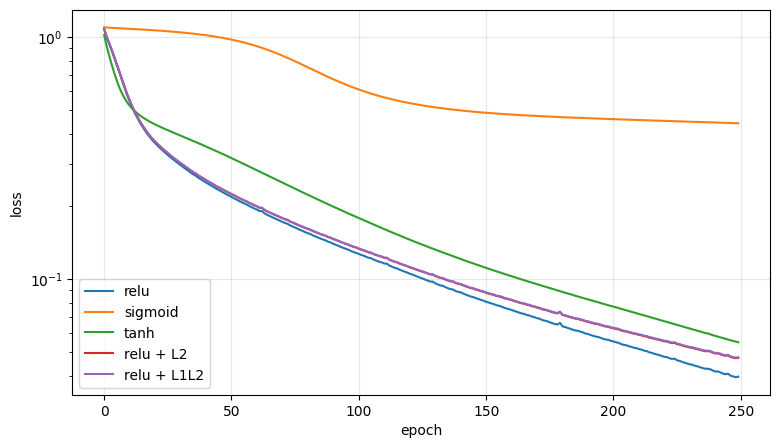

In [15]:
plt.figure(figsize=(9, 5))
for name, model in my_models.items():
    plt.plot(model.loss_history_, label=name)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Сравнение со sklearn, TensorFlow/Keras и PyTorch



In [16]:
comparison = []

my_model = my_models["relu"]
comparison.append({"model": "MyMLP NumPy", "accuracy": accuracy_score(y_test, my_model.predict(X_test))})

sk_model = MLPClassifier(
    hidden_layer_sizes=(32, 16), activation="relu", solver="sgd",
    learning_rate_init=0.03, batch_size=64, max_iter=250,
    random_state=SEED
)
sk_model.fit(X_train, y_train)
comparison.append({"model": "sklearn MLPClassifier", "accuracy": accuracy_score(y_test, sk_model.predict(X_test))})

pd.DataFrame(comparison)


,model,accuracy
0,MyMLP NumPy,0.936000
1,sklearn MLPClassifier,0.933333


In [17]:
import tensorflow as tf
tf.random.set_seed(SEED)
keras_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(12,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(3, activation="softmax"),
    ])
keras_model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.03),
        loss="sparse_categorical_crossentropy", metrics=["accuracy"])
keras_model.fit(X_train, y_train, epochs=250, batch_size=64, verbose=0)
keras_pred = keras_model.predict(X_test, verbose=0).argmax(axis=1)
comparison.append({"model": "TensorFlow/Keras", "accuracy": accuracy_score(y_test, keras_pred)})


In [18]:
import torch
import torch.nn as nn

torch.manual_seed(SEED)
net = nn.Sequential(nn.Linear(12, 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 3))
opt = torch.optim.SGD(net.parameters(), lr=0.03)
loss_fn = nn.CrossEntropyLoss()
Xt = torch.tensor(X_train, dtype=torch.float32)
yt = torch.tensor(y_train, dtype=torch.long)
gen = torch.Generator().manual_seed(SEED)
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Xt, yt), batch_size=64, shuffle=True, generator=gen
)
for _ in range(250):
    for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(net(xb), yb)
            loss.backward()
            opt.step()
with torch.no_grad():
        pred_torch = net(torch.tensor(X_test, dtype=torch.float32)).argmax(1).numpy()
comparison.append({"model": "PyTorch", "accuracy": accuracy_score(y_test, pred_torch)})

pd.DataFrame(comparison).sort_values("accuracy", ascending=False)


,model,accuracy
2,TensorFlow/Keras,0.941333
0,MyMLP NumPy,0.936000
1,sklearn MLPClassifier,0.933333
3,PyTorch,0.928000


## Регрессия

Для регрессии меняю только последний слой на линейный и функцию потерь на MSE.


In [19]:
Xr, yr = make_regression(
    n_samples=1200, n_features=8, n_informative=7,
    noise=12.0, random_state=SEED
)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.25, random_state=SEED
)
x_scaler = StandardScaler()
y_scaler = StandardScaler()
Xr_train = x_scaler.fit_transform(Xr_train)
Xr_test = x_scaler.transform(Xr_test)
yr_train_s = y_scaler.fit_transform(yr_train.reshape(-1, 1)).reshape(-1)

reg_model = MyMLP(
    [8, 32, 16, 1], ["relu", "relu", "linear"],
    task="regression", lr=0.01, l2=1e-4, seed=SEED
)
reg_model.fit(Xr_train, yr_train_s, epochs=300, batch_size=64)
pred_scaled = reg_model.predict(Xr_test)
pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)

sk_reg = MLPRegressor(
    hidden_layer_sizes=(32, 16), activation="relu", solver="sgd",
    learning_rate_init=0.01, batch_size=64, max_iter=300,
    random_state=SEED
)
sk_reg.fit(Xr_train, yr_train_s)
sk_pred_s = sk_reg.predict(Xr_test)
sk_pred = y_scaler.inverse_transform(sk_pred_s.reshape(-1, 1)).reshape(-1)

pd.DataFrame([
    {"model": "MyMLP NumPy", "RMSE": mean_squared_error(yr_test, pred) ** 0.5},
    {"model": "sklearn MLPRegressor", "RMSE": mean_squared_error(yr_test, sk_pred) ** 0.5},
])


,model,RMSE
0,MyMLP NumPy,22.205348
1,sklearn MLPRegressor,16.606686


## Вывод

Главная часть MLP - это цепочка матричных умножений и нелинейностей. ReLU в этих опытах обычно обучается быстрее сигмоиды. L1 делает веса более разреженными, L2 не дает им сильно расти. Реализации из библиотек удобнее и быстрее, но собственный класс помогает понять, как все устроено внутри, было интересно его написать
